In [1]:
import earthaccess
import xarray as xr
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt

# requires pip-system-certs
auth = earthaccess.login(persist=True)

/home/desvignese/NISAR/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
Zones = {
    'Mera': ((86.80148,27.64484, 86.94120,27.75825), 'EPSG:4326')     # projection EPSG:4623
} # Area you want to crop and download, ((lon_min, lat_min, lon_max, lat_max), Projection)

group_path = "/science/LSAR/GCOV/grids/frequencyA" # Path to a product, frequancyA has quadpol, B as Dual pol

spatial_extent = Zones['Mera'][0]

FILTERS = ['120_D', 'QPDH'] # Filters you want to apply to the data search (relative orbit number, A or D (ascending or Descending)... see documentation) 

# Orbites relatives : 048_D, 120_D
# polarisation: QPDH, DHDH

In [10]:
results = earthaccess.search_data(
    short_name='NISAR_L2_GCOV_BETA_V1', # The product to access, there is many more, see doc.
    count=-1, 
    bounding_box=spatial_extent, 
    cloud_hosted=True,
)

# Filtering the URL 
mask = np.where([all(f in result["meta"]['native-id'] for f in FILTERS) for result in results])[0]
results = [results[id] for id in mask]
names = [result["meta"]['native-id'] for result in results]

print(len(results), 'files found') 

# Configuration connection
fsspec_config = {
    'cache_type': 'background',
    'block_size': 16*1024*1024,  # 16 MB
}
fs = earthaccess.get_fsspec_https_session()

https_links = [result.data_links(access='external') for result in results]
files = [fs.open(https_link[0], **fsspec_config) for https_link in https_links]

# Creating a list of datatrees, takes a few minutes
datatrees = [xr.open_datatree(
                f,
                engine='h5netcdf',
                decode_timedelta=False,
                phony_dims="access", 
                chunks = 'auto',
                )[group_path]
for f in files]

/home/desvignese/NISAR/.venv/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


4 files found


# Adding a time dimension

In [11]:
import re
from urllib.parse import urlparse
from datetime import datetime
from pathlib import PurePosixPath

NISAR_TS_RE = re.compile(r"_(\d{8}T\d{6})_")

def nisar_start_time_from_url(url: str) -> datetime:
    path = urlparse(url).path
    name = PurePosixPath(path).name
    
    m = NISAR_TS_RE.search(name)
    if not m:
        raise ValueError(f"No NISAR timestamp found in: {url}")
    
    return datetime.strptime(m.group(1), "%Y%m%dT%H%M%S")

dts = [nisar_start_time_from_url(url[0]) for url in https_links]


In [12]:
%%time

datasets = [
    tree.ds.assign_coords(time=dt).expand_dims(time=1)
    for dt, tree in zip(dts, datatrees)
]

datasets[0]

CPU times: user 66.1 ms, sys: 0 ns, total: 66.1 ms
Wall time: 65.8 ms


<xarray.Dataset> Size: 22GB
Dimensions:                (time: 1, yCoordinates: 16956, xCoordinates: 17244,
                            phony_dim_0: 10, phony_dim_1: 4)
Coordinates:
  * time                   (time) datetime64[us] 8B 2025-12-12T12:50:28
  * yCoordinates           (yCoordinates) float64 136kB 3.127e+06 ... 2.788e+06
  * xCoordinates           (xCoordinates) float64 138kB 4.039e+05 ... 7.488e+05
Dimensions without coordinates: phony_dim_0, phony_dim_1
Data variables: (12/19)
    HHHH                   (time, yCoordinates, xCoordinates) float32 1GB dask.array<chunksize=(1, 5632, 5632), meta=np.ndarray>
    HHHV                   (time, yCoordinates, xCoordinates) complex64 2GB dask.array<chunksize=(1, 4096, 4096), meta=np.ndarray>
    HHVH                   (time, yCoordinates, xCoordinates) complex64 2GB dask.array<chunksize=(1, 4096, 4096), meta=np.ndarray>
    HHVV                   (time, yCoordinates, xCoordinates) complex64 2GB dask.array<chunksize=(1, 4096, 4096), meta=np.ndarray>
    HVHV                   (time, yCoordinates, xCoordinates) float32 1GB dask.array<chunksize=(1, 5632, 5632), meta=np.ndarray>
    HVVH                   (time, yCoordinates, xCoordinates) complex64 2GB dask.array<chunksize=(1, 4096, 4096), meta=np.ndarray>
    ...                     ...
    numberOfLooks          (time, yCoordinates, xCoordinates) float32 1GB dask.array<chunksize=(1, 5632, 5632), meta=np.ndarray>
    numberOfSubSwaths      (time) uint8 1B 4
    projection             (time) uint32 4B 32645
    rtcGammaToSigmaFactor  (time, yCoordinates, xCoordinates) float32 1GB dask.array<chunksize=(1, 5632, 5632), meta=np.ndarray>
    xCoordinateSpacing     (time) float64 8B 20.0
    yCoordinateSpacing     (time) float64 8B -20.0

# Projection and croping to the Area

In [13]:
%%time

dataarrays = [
    ds[['HHHH', 'HVHV', 'VVVV', 'VHVH']].to_dataarray(dim="band").assign_coords(projection = ds.projection)
    for ds in datasets
]

dataarrays[0]

CPU times: user 20.5 ms, sys: 0 ns, total: 20.5 ms
Wall time: 19.7 ms


<xarray.DataArray (band: 4, time: 1, yCoordinates: 16956, xCoordinates: 17244)> Size: 5GB
dask.array<stack, shape=(4, 1, 16956, 17244), dtype=float32, chunksize=(1, 1, 5692, 5632), chunktype=numpy.ndarray>
Coordinates:
  * band          (band) object 32B 'HHHH' 'HVHV' 'VVVV' 'VHVH'
  * time          (time) datetime64[us] 8B 2025-12-12T12:50:28
    projection    (time) uint32 4B 32645
  * yCoordinates  (yCoordinates) float64 136kB 3.127e+06 3.127e+06 ... 2.788e+06
  * xCoordinates  (xCoordinates) float64 138kB 4.039e+05 4.04e+05 ... 7.488e+05

In [14]:
import rioxarray

dataarrays_proj =  [da.rio.write_crs(f"EPSG:{da.isel(time=0).projection.item()}") for da in dataarrays]

bbox4326 = dict(minx=spatial_extent[0], miny=spatial_extent[1], maxx=spatial_extent[2], maxy=spatial_extent[3], crs="EPSG:4326")
da_subset = [da.rio.clip_box(**bbox4326) for da in dataarrays_proj]

In [15]:
ts = xr.concat(da_subset, dim="time")
ts

<xarray.DataArray (band: 4, time: 4, yCoordinates: 629, xCoordinates: 691)> Size: 28MB
dask.array<concatenate, shape=(4, 4, 629, 691), dtype=float32, chunksize=(1, 1, 629, 691), chunktype=numpy.ndarray>
Coordinates:
  * band          (band) object 32B 'HHHH' 'HVHV' 'VVVV' 'VHVH'
  * time          (time) datetime64[us] 32B 2025-12-12T12:50:28 ... 2026-01-1...
    projection    (time) uint32 16B 32645 32645 32645 32645
  * yCoordinates  (yCoordinates) float64 5kB 3.07e+06 3.07e+06 ... 3.058e+06
  * xCoordinates  (xCoordinates) float64 6kB 4.804e+05 4.804e+05 ... 4.942e+05
    spatial_ref   int64 8B 0

## Processing to save the tif files

In [17]:
for da in da_subset:
# Adding band names as attributes (will be saved)
    da.attrs.update({'long_name': ['HHHH', 'HVHV', 'VVVV', 'VHVH']})


In [ ]:
import os

path = '/home/desvignese/NISAR/Data/NISAR_GCOV/Mera'
os.makedirs(path, exist_ok=True)

for da, title in zip(da_subset, names):
    # print(da)
    da.isel(time=0).rio.to_raster(os.path.join(path, f'{title}.tif'))
    print(da.time.values, title)

da

Visualisation of the area of interest over the overall footprint of the image

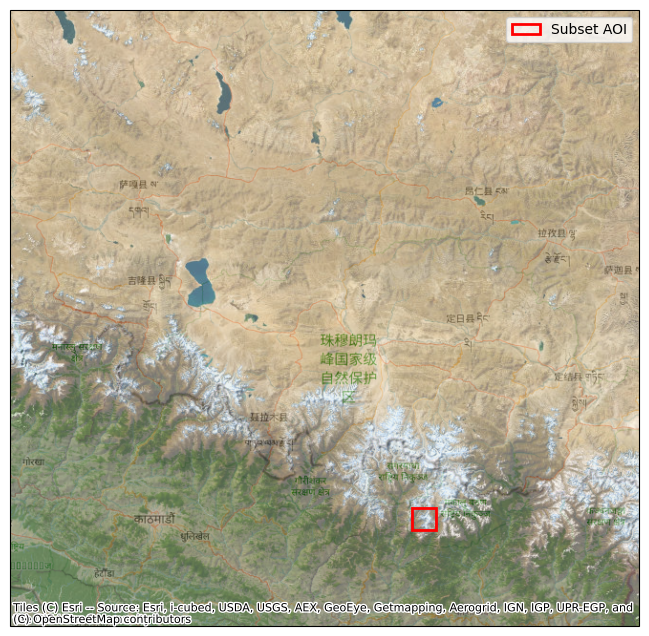

In [40]:
import cartopy.crs as ccrs
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig = plt.figure(figsize=(10,8))     

ax = fig.add_subplot(1, 1, 1, projection=ccrs.epsg(3857))

minx, miny, maxx, maxy = dataarrays_proj[0].rio.transform_bounds("EPSG:3857", densify_pts=21)

ax.set_extent(
    [minx, maxx, miny, maxy],
    crs=ccrs.epsg(3857))

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.5)

sub_minx, sub_miny, sub_maxx, sub_maxy = da_subset[0].rio.transform_bounds("EPSG:3857", densify_pts=21)
rect = patches.Rectangle(
    (sub_minx, sub_miny),
    sub_maxx - sub_minx,
    sub_maxy - sub_miny, 
    linewidth=2, 
    edgecolor="red", 
    facecolor="none",
    label="Subset AOI",
    transform=ccrs.epsg(3857)
)
ax.add_patch(rect)

ax.legend(handles=[rect])
plt.show()

## Opening and reading presaved Data

In [71]:
arrays = []

for file in os.listdir(path):
    date = np.datetime64(file.split('_')[0])
    arrays.append(xr.open_dataarray(os.path.join(path, file)).assign_coords(time=date).expand_dims(time=1))
    
NISAR = xr.concat(arrays, dim='time')
NISAR

<xarray.DataArray 'band_data' (time: 4, band: 4, y: 629, x: 691)> Size: 28MB
array([[[[0.25066757, 0.15814209, 0.08684444, ..., 0.11829185,
          0.13409424, 0.23560715],
         [0.1833744 , 0.21582031, 0.28259277, ..., 0.19058609,
          0.15257835, 0.13510704],
         [0.06958675, 0.2893982 , 0.4085617 , ..., 0.22281075,
          0.3142624 , 0.1437664 ],
         ...,
         [0.05458307, 0.39678192, 0.91955566, ..., 0.02288342,
          0.05094147, 0.09810066],
         [0.07857132, 1.0003815 ,        nan, ..., 0.09469891,
          0.11885548, 0.23604774],
         [0.08032799, 0.51976013, 3.800293  , ..., 0.11492348,
          0.26108932, 0.28206635]],

        [[0.11936474, 0.05717134, 0.03990793, ..., 0.0269897 ,
          0.01036572, 0.02826762],
         [0.12282276, 0.04042482, 0.024894  , ..., 0.02077699,
          0.01421988, 0.01125205],
         [0.03281069, 0.06453991, 0.0200541 , ..., 0.03553438,
          0.03650475, 0.03546238],
...
         [0.03646135, 0.08746243, 0.43790817, ..., 0.07561779,
          0.13883781, 0.24905586],
         [0.0342927 , 0.25356674,        nan, ..., 0.06575871,
          0.11190414, 0.40547562],
         [0.03976917, 0.19903755, 1.0088654 , ..., 0.20021248,
          0.23141861, 0.13728333]],

        [[0.03929567, 0.06835079, 0.04619503, ..., 0.02070665,
          0.04443455, 0.05787849],
         [0.11854267, 0.11082172, 0.08429623, ..., 0.01411283,
          0.01399744, 0.04650688],
         [0.02945971, 0.06523228, 0.03736544, ..., 0.01638532,
          0.02490187, 0.02749848],
         ...,
         [0.01791096, 0.06331539, 0.37585068, ..., 0.02703404,
          0.05115128, 0.01763511],
         [0.02604723, 0.5666199 ,        nan, ..., 0.01763105,
          0.09604454, 0.14289284],
         [0.03364182, 0.20746613, 0.24330139, ..., 0.01142693,
          0.01417148, 0.05222082]]]], dtype=float32)
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * x            (x) float64 6kB 4.804e+05 4.804e+05 ... 4.942e+05 4.942e+05
  * y            (y) float64 5kB 3.07e+06 3.07e+06 ... 3.058e+06 3.058e+06
    spatial_ref  int64 8B 0
  * time         (time) datetime64[s] 32B 2025-11-25T12:58:13 ... 2026-01-12T...
Attributes:
    AREA_OR_POINT:  Area

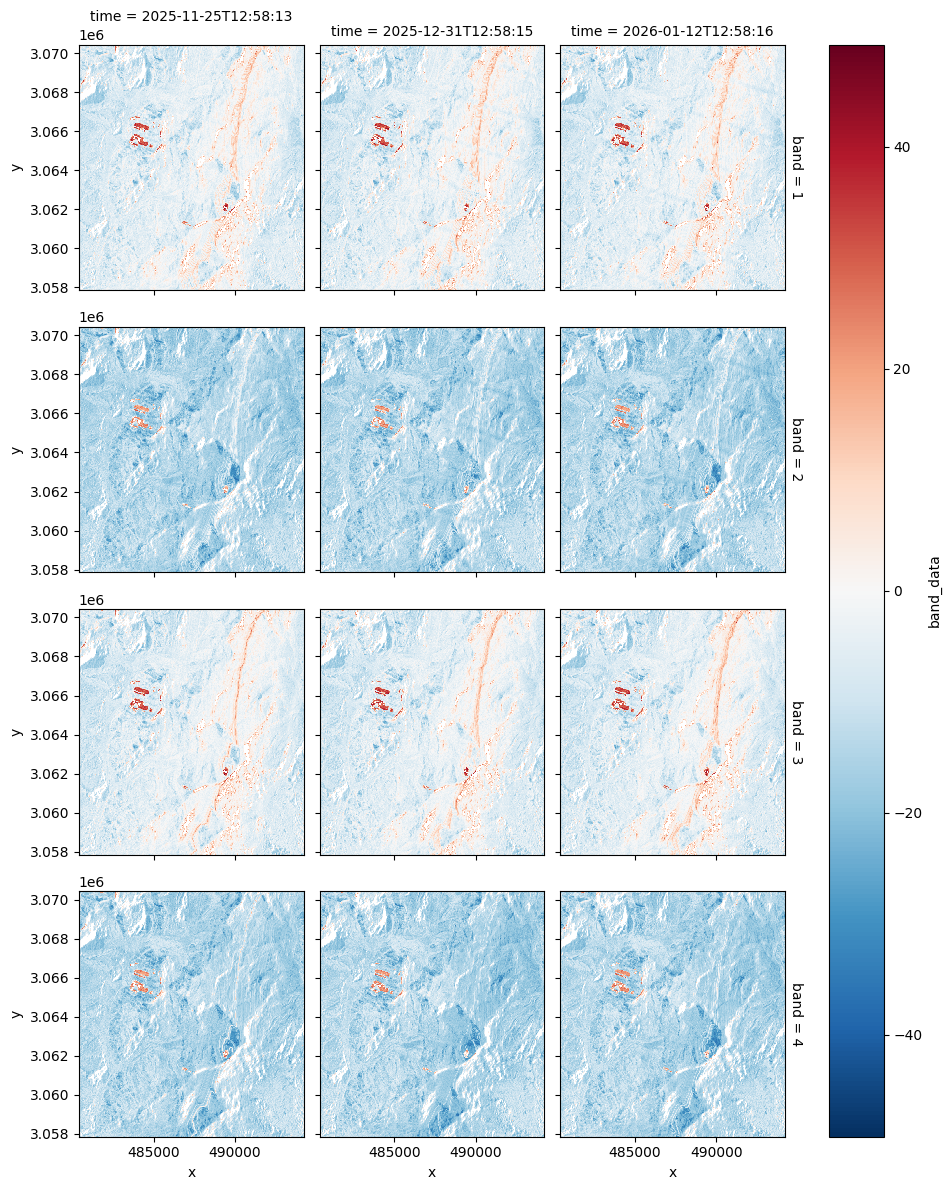

In [ ]:
NISAR_dB = 10 * np.log10(NISAR.where(NISAR>0))
NISAR_dB.plot.pcolormesh(col='time', row='band')